# 04_gsgb_preprocess

Read GSGB Excel tables, rename variables, derive PGSI bins, and save analysis-ready outputs.

In [1]:
import pandas as pd
from pathlib import Path

# Load GSGB workbook
GSGB_XLSX = Path("data/raw/GSGB/GSGB_Y2W4_FINAL__2.xlsx")
xls = pd.ExcelFile(GSGB_XLSX, engine="openpyxl")

# Identify required tables
sheet_a8  = [s for s in xls.sheet_names if "a.8"  in s.lower()][0]
sheet_a11 = [s for s in xls.sheet_names if "a.11" in s.lower()][0]
sheet_a14 = [s for s in xls.sheet_names if "a.14" in s.lower()][0]
sheet_a15 = [s for s in xls.sheet_names if "a.15" in s.lower()][0]

# Save sheet registry (simple)
pd.DataFrame({"sheet_names": xls.sheet_names}) \
    .to_csv("data/interim/gsgb_sheet_registry.csv", index=False)

xls.sheet_names

['Coversheet',
 'Sheet1',
 'Notes and definitions',
 'Table of contents',
 'Table A.1',
 'Table A.2',
 'Table A.3',
 'Table A.4',
 'Table A.5',
 'Table A.6',
 'Table A.7',
 'Table A.8 ',
 'Table A.9',
 'Table A.10',
 'Table A.11',
 'Table A.13',
 'Table A.12',
 'Table A.14',
 'Table A.15']

In [2]:
# Output folder
OUT_RAW = Path("data/interim")
OUT_RAW.mkdir(parents=True, exist_ok=True)

# Read each sheet once (simple & consistent)
df_a8_raw  = pd.read_excel(GSGB_XLSX, sheet_name=sheet_a8,  engine="openpyxl")
df_a11_raw = pd.read_excel(GSGB_XLSX, sheet_name=sheet_a11, engine="openpyxl")
df_a14_raw = pd.read_excel(GSGB_XLSX, sheet_name=sheet_a14, engine="openpyxl")
df_a15_raw = pd.read_excel(GSGB_XLSX, sheet_name=sheet_a15, engine="openpyxl")

# Table A.15 has mixed types → convert everything to string
df_a15_raw = df_a15_raw.astype(str)


# Save raw versions (consistent with HSE/UKHLS)
df_a8_raw.to_parquet( OUT_RAW / "gsgb_a8_raw.parquet",  index=False )
df_a11_raw.to_parquet(OUT_RAW / "gsgb_a11_raw.parquet", index=False )
df_a14_raw.to_parquet(OUT_RAW / "gsgb_a14_raw.parquet", index=False )
df_a15_raw.to_parquet(OUT_RAW / "gsgb_a15_raw.parquet", index=False )

# --- PREVIEW each raw table (head only) ---

print("=== Table A.8 Raw Preview ===")
display(df_a8_raw.head())

print("=== Table A.11 Raw Preview ===")
display(df_a11_raw.head())

print("=== Table A.14 Raw Preview ===")
display(df_a14_raw.head())

print("=== Table A.15 Raw Preview ===")
display(df_a15_raw.head())

=== Table A.8 Raw Preview ===


,Sex and age group (years),Participation in the past four weeks\n(percentage),Participation in the past four weeks excluding lottery draw only players i\n(percentage),"Unweighted bases (number) ii,iii","Weighted bases (number) ii,iii"
0,All participants,0.463743,0.276684,5130.0,5133.497185
1,All males,0.506754,0.322274,2284.0,2491.040487
2,All females,0.422028,0.232500,2842.0,2637.116383
3,18 to 24,0.375285,0.348435,332.0,535.070385
4,25 to 34,0.415999,0.342749,781.0,891.145423


=== Table A.11 Raw Preview ===


,Gambling activity,All participants\n(percentage),All males\n(percentage),All females\n(percentage)
0,Tickets for National Lottery draws i,0.287665,0.314672,0.261665
1,Tickets for National Lottery draws bought o...,0.232368,0.264003,0.202286
2,Tickets National Lottery draws bought in pe...,0.154503,0.163516,0.145331
3,Tickets for other charity lottery draws i,0.148719,0.134662,0.161332
4,Tickets for other charity lottery draws bou...,0.130423,0.116224,0.143117


=== Table A.14 Raw Preview ===


,Reasons for gambling: I take part in these activities…,All participants: \nGambled in past 12 months\n(percentage),All males: \nGambled in the past 12 months\n(percentage),All females: \nGambled in the past 12 months\n(percentage),18 to 24: \nGambled in the past 12 months\n(percentage),25 to 34: \nGambled in the past 12 months\n(percentage),35 to 44: \nGambled in the past 12 months\n(percentage),45 to 54: \nGambled in the past 12 months\n(percentage),55 to 64: \nGambled in the past 12 months\n(percentage),65 to 74: \nGambled in the past 12 months\n(percentage),75 plus: \nGambled in the past 12 months\n(percentage)
0,For the chance of winning big money,0.852945,0.854740,0.850524,0.714940,0.864655,0.895722,0.903424,0.874993,0.823251,0.791475
1,Because it's fun,0.733946,0.742520,0.723949,0.865248,0.834662,0.771926,0.745799,0.684255,0.590243,0.577246
2,As a hobby or pastime,0.294230,0.360064,0.225230,0.379044,0.381727,0.343050,0.280611,0.241077,0.197528,0.182411
3,To escape boredom or to fill my time,0.232753,0.283335,0.178708,0.351803,0.306029,0.292760,0.204974,0.186777,0.112408,0.130808
4,Because I'm worried about not winning if I don...,0.197307,0.235761,0.157522,0.183500,0.219491,0.248081,0.221176,0.171834,0.118495,0.177330


=== Table A.15 Raw Preview ===


,Feelings towards gambling,All participants: Gambled in the past 12 months\n(percentage),All participants: Gambled in the past 12 months excluding lottery draw only players ii\n(percentage)
0,0 (Hated it),0.04977351185311441,0.04898405868940596
1,1,0.016328105180994673,0.013341773203073498
2,2,0.02434850630164565,0.02075912049001315
3,3,0.05031328318442705,0.045126819840307204
4,4,0.06500366950479035,0.060534025447480905


In [17]:
# =============================================================
# B.1 — GSGB A.8 (Participation) — MODEL-READY CLEAN DATASET
# =============================================================

import pandas as pd
from pathlib import Path
import re

# ----------------------------------------------------
# 1. Load raw A.8 table (already saved in interim)
# ----------------------------------------------------
df_a8_raw = pd.read_parquet("data/interim/gsgb_a8_raw.parquet")

# ----------------------------------------------------
# 2. Clean column names
# ----------------------------------------------------
df_a8 = df_a8_raw.copy()
df_a8.columns = df_a8.columns.str.strip()

# Rename columns to consistent names
df_a8 = df_a8.rename(columns={
    "Sex and age group (years)": "group",
    "Participation in the past four weeks\n(percentage)": "pct_all",
    "Participation in the past four weeks excluding lottery draw only players i\n(percentage)": "pct_no_lottery",
    "Unweighted bases (number) ii,iii": "unweighted_n",
    "Weighted bases (number) ii,iii": "weighted_n"
})

# ----------------------------------------------------
# 3. Clean and normalize group labels
# ----------------------------------------------------
df_a8["group_clean"] = (
    df_a8["group"]
    .astype(str)
    .str.strip()
    .str.replace("  ", " ", regex=False)
)

# ----------------------------------------------------
# 4. Categorise row types
# ----------------------------------------------------
def classify(g):
    if g.startswith("All "):
        if g in ["All males", "All females"]:
            return "sex"
        else:
            return "all"
    elif g.split(" ")[0] in ["Males", "Females"]:
        return "sex_age"
    elif re.match(r"^\d+", g):   # Age groups starting with a digit
        return "age"
    else:
        return "other"

df_a8["group_type"] = df_a8["group_clean"].apply(classify)

# ----------------------------------------------------
# 5. Extract sex
# ----------------------------------------------------
df_a8["sex"] = None
df_a8.loc[df_a8["group_clean"] == "All males",   "sex"] = "male"
df_a8.loc[df_a8["group_clean"] == "All females", "sex"] = "female"
df_a8.loc[df_a8["group_clean"].str.startswith("Males "),   "sex"] = "male"
df_a8.loc[df_a8["group_clean"].str.startswith("Females "), "sex"] = "female"

# ----------------------------------------------------
# 6. Extract age_group for pure age and sex_age rows
# ----------------------------------------------------
def extract_age(label):
    match = re.search(r"(\d+ to \d+|\d+ plus)", label)
    return match.group(1) if match else None

df_a8["age_group"] = df_a8["group_clean"].apply(extract_age)

# ----------------------------------------------------
# 7. Metadata
# ----------------------------------------------------
df_a8["survey_year"] = 2023

# ----------------------------------------------------
# 8. Save model-ready version
# ----------------------------------------------------
OUT_MODEL = Path("data/processed/model-ready")
OUT_MODEL.mkdir(parents=True, exist_ok=True)

df_a8.to_parquet(OUT_MODEL / "gsgb_a8_model_ready.parquet", index=False)

print("=== GSGB A.8 MODEL-READY SAVED ===")
display(df_a8.head(15))

print("\nUnique group_clean:\n", df_a8["group_clean"].unique())
print("\nUnique group_type:\n", df_a8["group_type"].unique())
print("\nUnique sex:\n", df_a8["sex"].unique())
print("\nUnique age_group:\n", df_a8["age_group"].unique())

# ----------------------------------------------------
# PATCH A.8 — Remove metadata/footer rows cleanly
# ----------------------------------------------------
df_a8 = df_a8[~df_a8["group_clean"].str.contains("Base", case=False, na=False)]
df_a8 = df_a8[~df_a8["group_clean"].str.contains("i ", case=False, na=False)]
df_a8 = df_a8[~df_a8["group_clean"].str.contains("Table", case=False, na=False)]

# remove rows where ALL numeric values are missing (guaranteed metadata)
num_cols = ["pct_all", "pct_no_lottery", "unweighted_n", "weighted_n"]
df_a8 = df_a8.dropna(subset=num_cols, how="all")

# remove accidental 'other' classification
df_a8.loc[df_a8["group_type"] == "other", "group_type"] = "all"


=== GSGB A.8 MODEL-READY SAVED ===


,group,pct_all,pct_no_lottery,unweighted_n,weighted_n,group_clean,group_type,sex,age_group,survey_year
0,All participants,0.463743,0.276684,5130.0,5133.497185,All participants,all,None,None,2023
1,All males,0.506754,0.322274,2284.0,2491.040487,All males,sex,male,None,2023
2,All females,0.422028,0.232500,2842.0,2637.116383,All females,sex,female,None,2023
3,18 to 24,0.375285,0.348435,332.0,535.070385,18 to 24,age,None,18 to 24,2023
4,25 to 34,0.415999,0.342749,781.0,891.145423,25 to 34,age,None,25 to 34,2023
5,35 to 44,0.528024,0.360006,856.0,886.030772,35 to 44,age,None,35 to 44,2023
6,45 to 54,0.519635,0.273869,734.0,783.648323,45 to 54,age,None,45 to 54,2023
7,55 to 64,0.518984,0.245724,876.0,822.752271,55 to 64,age,None,55 to 64,2023
8,65 to 74,0.447515,0.174116,911.0,709.042489,65 to 74,age,None,65 to 74,2023
9,75 plus,0.375131,0.136214,640.0,505.807521,75 plus,age,None,75 plus,2023



Unique group_clean:
 ['All participants' 'All males' 'All females' '18 to 24' '25 to 34'
 '35 to 44' '45 to 54' '55 to 64' '65 to 74' '75 plus' 'Males 18 to 24'
 'Males 25 to 34' 'Males 35 to 44' 'Males 45 to 54' 'Males 55 to 64'
 'Males 65 to 74' 'Males 75 plus' 'Females 18 to 24' 'Females 25 to 34'
 'Females 35 to 44' 'Females 45 to 54' 'Females 55 to 64'
 'Females 65 to 74' 'Females 75 plus' 'Base: Productive individuals'
 'i Excluding participants who had only played National Lottery or other charity lottery draw based games.'
 'ii Sex could not be derived for 4 participants who did not respond to the questions.'
 'iii Gambling participation in the past four weeks could not be derived for 61 participants who did not respond to the questions.'
 'None'
 'Table A.8: Gambling participation in the past four weeks (including and excluding Lottery draw products only players), by sex and age']

Unique group_type:
 ['all' 'sex' 'age' 'sex_age' 'other']

Unique sex:
 [None 'male' 'female']


In [4]:
# =============================================================
# B.2 — GSGB Table A.11 (Gambling Activities) — MODEL-READY
# =============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# -----------------------------------------
# 1. Load raw A.11
# -----------------------------------------
df_a11 = pd.read_parquet("data/interim/gsgb_a11_raw.parquet")

# -----------------------------------------
# 2. Clean column names
# -----------------------------------------
df_a11.columns = df_a11.columns.str.strip()

# Identify first column = activity description
activity_col = df_a11.columns[0]

# Rename it for consistency
df_a11 = df_a11.rename(columns={activity_col: "activity"})

# -----------------------------------------
# 3. Remove blank and footnote rows
# -----------------------------------------
df_a11 = df_a11[df_a11["activity"].notna()]
df_a11 = df_a11[~df_a11["activity"].str.contains("Table A.11", na=False, case=False)]
df_a11 = df_a11[~df_a11["activity"].str.contains("Base:", na=False, case=False)]
df_a11 = df_a11[~df_a11["activity"].str.contains("i ", na=False, case=False)]
df_a11 = df_a11[~df_a11["activity"].str.contains("ii ", na=False, case=False)]

# Clean activity text
df_a11["activity"] = df_a11["activity"].astype(str).str.strip()

# -----------------------------------------
# 4. Convert percentage columns to numeric
# -----------------------------------------
numeric_cols = df_a11.columns.drop("activity")

for col in numeric_cols:
    df_a11[col] = (
        df_a11[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace("*", "", regex=False)
        .str.strip()
    )
    df_a11[col] = pd.to_numeric(df_a11[col], errors="coerce")

# -----------------------------------------
# 5. Add survey year
# -----------------------------------------
df_a11["survey_year"] = 2023

# -----------------------------------------
# 6. Save model-ready version
# -----------------------------------------
OUT_MODEL = Path("data/processed/model-ready")
OUT_MODEL.mkdir(parents=True, exist_ok=True)

df_a11.to_parquet(OUT_MODEL / "gsgb_a11_model_ready.parquet", index=False)

print("=== GSGB A.11 model-ready saved ===")
display(df_a11.head(10))
print(df_a11.columns)


=== GSGB A.11 model-ready saved ===


,activity,All participants\n(percentage),All males\n(percentage),All females\n(percentage),survey_year
0,Tickets for National Lottery draws i,0.287665,0.314672,0.261665,2023
1,Tickets for National Lottery draws bought online,0.232368,0.264003,0.202286,2023
2,Tickets National Lottery draws bought in person,0.154503,0.163516,0.145331,2023
3,Tickets for other charity lottery draws i,0.148719,0.134662,0.161332,2023
4,Tickets for other charity lottery draws bought...,0.130423,0.116224,0.143117,2023
5,Tickets for other charity lottery draws bought...,0.054118,0.059396,0.048663,2023
6,Scratchcards i,0.121845,0.112042,0.130009,2023
7,National Lottery scratchcards,0.107924,0.101369,0.112985,2023
8,Other scratchcards,0.044935,0.044314,0.044259,2023
9,Online instant win games,0.071808,0.081994,0.061774,2023


Index(['activity', 'All participants\n(percentage)', 'All males\n(percentage)',
       'All females\n(percentage)', 'survey_year'],
      dtype='object')


In [12]:
# ==============================================
# Table A.14 — 
# ==============================================

df_a14 = pd.read_parquet("data/processed/model-ready/gsgb_a14_model_ready.parquet").copy()

# Step 1 — drop fully blank rows or NA reason
df_a14 = df_a14[df_a14["reason"].notna()]

# Step 2 — remove footers (they contain words like 'Base', 'Weighted', 'Unweighted')
df_a14 = df_a14[
    ~df_a14["reason"].str.contains("Base", case=False, na=False) &
    ~df_a14["reason"].str.contains("Weighted", case=False, na=False) &
    ~df_a14["reason"].str.contains("Unweighted", case=False, na=False)
]

# Step 3 — rename columns cleanly
df_a14 = df_a14.rename(columns={
    "All males: \nGambled in the past 12 months\n(percentage)": "pct_male",
    "All females: \nGambled in the past 12 months\n(percentage)": "pct_female",
})

# Keep only sex columns
df_plot = df_a14[["reason", "pct_male", "pct_female"]].copy()

# Melt for plotting
df_long = df_plot.melt(
    id_vars="reason",
    value_vars=["pct_male", "pct_female"],
    var_name="sex",
    value_name="pct"
)

# Clean sex labels
df_long["sex"] = df_long["sex"].str.replace("pct_", "").str.capitalize()

df_long


,reason,sex,pct
0,For the chance of winning big money,Male,0.854740
1,Because it's fun,Male,0.742520
2,As a hobby or pastime,Male,0.360064
3,To escape boredom or to fill my time,Male,0.283335
4,"To compete with others (e.g. bookmaker, other ...",Male,0.148539
5,Because it's exciting,Male,0.597484
6,For the mental challenge or to learn about the...,Male,0.266764
7,To impress other people,Male,0.127785
8,To be sociable,Male,0.307442
9,Because it helps when I'm feeling tense,Male,0.148532


In [6]:
# =====================================================
# GSGB A.15 — Feelings Towards Gambling (IMPROVED NAMING)
# =====================================================

import pandas as pd

# Load raw A.15 sheet
df15 = pd.read_parquet("data/interim/gsgb_a15_raw.parquet").copy()

# 1. Standardize column names
df15.columns = df15.columns.str.strip()

df15 = df15.rename(columns={
    df15.columns[0]: "raw_feeling",
    df15.columns[1]: "pct_all_raw",
    df15.columns[2]: "pct_excl_lottery_raw"
})

# 2. Keep only rows that begin with 0–10
df15_clean = df15[df15["raw_feeling"].str.match(r"^\d")].copy()

# 3. Extract feeling score and label
df15_clean["feeling_score"] = df15_clean["raw_feeling"].str.extract(r"^(\d+)").astype(int)
df15_clean["feeling_label"] = df15_clean["raw_feeling"].str.extract(r"\((.*)\)")
df15_clean["feeling_label"] = df15_clean["feeling_label"].fillna("")

# 4. Numeric conversions
df15_clean["pct_all_gamblers"] = pd.to_numeric(df15_clean["pct_all_raw"], errors="coerce")
df15_clean["pct_excl_lottery_only"] = pd.to_numeric(df15_clean["pct_excl_lottery_raw"], errors="coerce")

# 5. Add survey year
df15_clean["survey_year"] = 2023

# 6. Final tidy output
df15_model_ready = df15_clean[[
    "feeling_score",
    "feeling_label",
    "pct_all_gamblers",
    "pct_excl_lottery_only",
    "survey_year"
]]

# Save
df15_model_ready.to_parquet(
    "data/processed/model-ready/gsgb_a15_model_ready.parquet",
    index=False
)

print("=== GSGB A.15 model-ready file updated with improved naming ===")
display(df15_model_ready)


=== GSGB A.15 model-ready file updated with improved naming ===


,feeling_score,feeling_label,pct_all_gamblers,pct_excl_lottery_only,survey_year
0,0,Hated it,0.049774,0.048984,2023
1,1,,0.016328,0.013342,2023
2,2,,0.024349,0.020759,2023
3,3,,0.050313,0.045127,2023
4,4,,0.065004,0.060534,2023
5,5,,0.382022,0.335213,2023
6,6,,0.115216,0.126011,2023
7,7,,0.133562,0.153017,2023
8,8,,0.102524,0.120911,2023
9,9,,0.020319,0.025200,2023


In [12]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("C:/Users/User/Documents/Github/Gambling_MentalHealth_MSc")
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"

gsgb_parquets = [
    "gsgb_a8_raw.parquet",
    "gsgb_a11_raw.parquet",
    "gsgb_a14_raw.parquet",
    "gsgb_a15_raw.parquet",
]

print("=== GSGB published tables (row counts) ===")
for fname in gsgb_parquets:
    path = DATA_INTERIM / fname
    df = pd.read_parquet(path)
    print(f"{fname}: shape {df.shape}")


=== GSGB published tables (row counts) ===
gsgb_a8_raw.parquet: shape (30, 5)
gsgb_a11_raw.parquet: shape (42, 4)
gsgb_a14_raw.parquet: shape (24, 11)
gsgb_a15_raw.parquet: shape (18, 3)


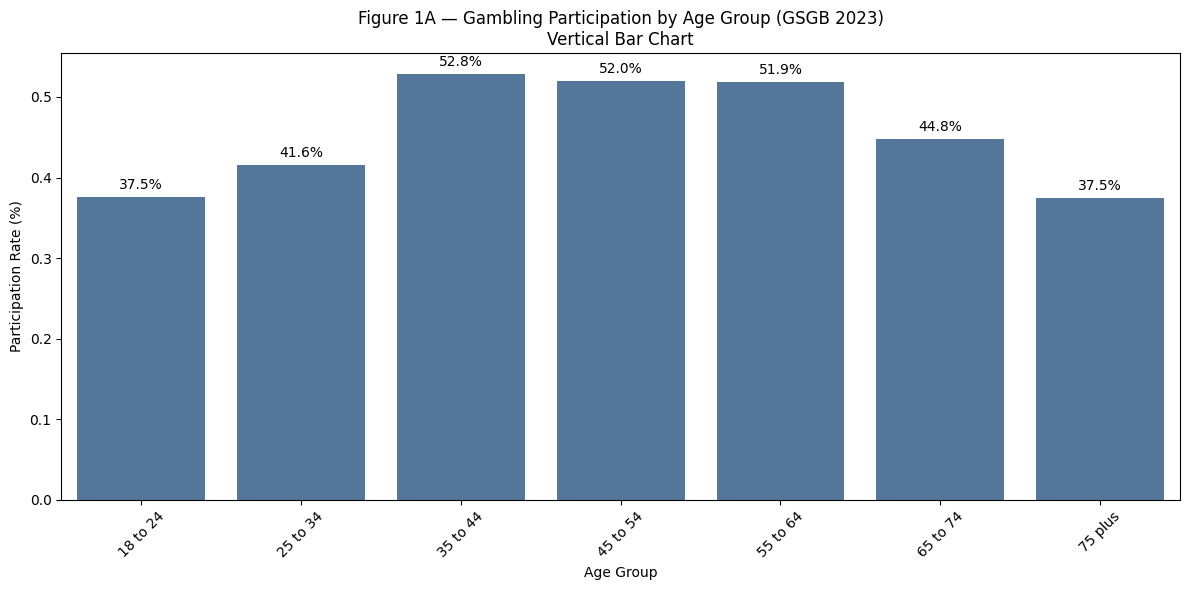

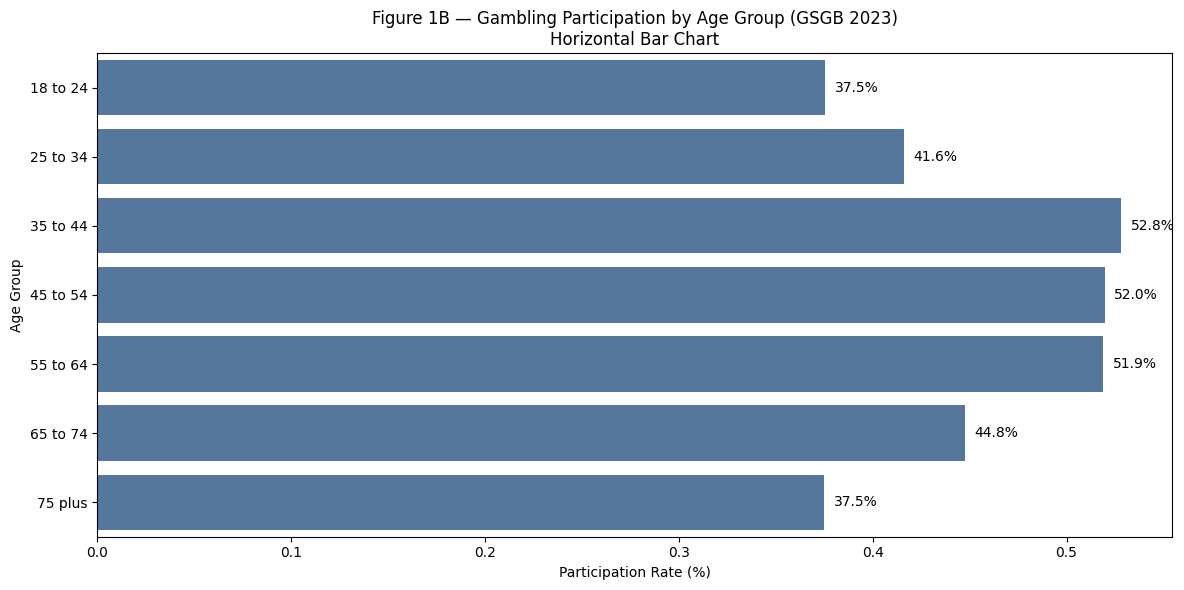

In [7]:
# ==========================================================
# GSGB Figure 1A & 1B — Participation by Age (GSGB 2023)
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Ensure df_age is fresh and clean
df_a8 = pd.read_parquet("data/processed/model-ready/gsgb_a8_model_ready.parquet")
df_age = df_a8[df_a8["group_type"] == "age"].copy()

# ------------------------------
# Sort age groups numerically
# ------------------------------
df_age["sort"] = (
    df_age["age_group"]
    .str.extract(r"^(\d+)")[0]
    .astype(float)
)

df_age = df_age.sort_values("sort")

# ==========================================================
# FIGURE 1A — Vertical Bar Chart
# ==========================================================

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_age,
    x="age_group",
    y="pct_all",
    color="#4a76a8"
)

# Annotate
for i, v in enumerate(df_age["pct_all"]):
    plt.text(i, v + 0.01, f"{v*100:.1f}%", ha="center")

plt.title("Figure 1A — Gambling Participation by Age Group (GSGB 2023)\nVertical Bar Chart")
plt.ylabel("Participation Rate (%)")
plt.xlabel("Age Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ==========================================================
# FIGURE 1B — Horizontal Bar Chart
# ==========================================================

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_age,
    y="age_group",
    x="pct_all",
    color="#4a76a8"
)

# Annotate
for i, v in enumerate(df_age["pct_all"]):
    plt.text(v + 0.005, i, f"{v*100:.1f}%", va="center")

plt.title("Figure 1B — Gambling Participation by Age Group (GSGB 2023)\nHorizontal Bar Chart")
plt.xlabel("Participation Rate (%)")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()


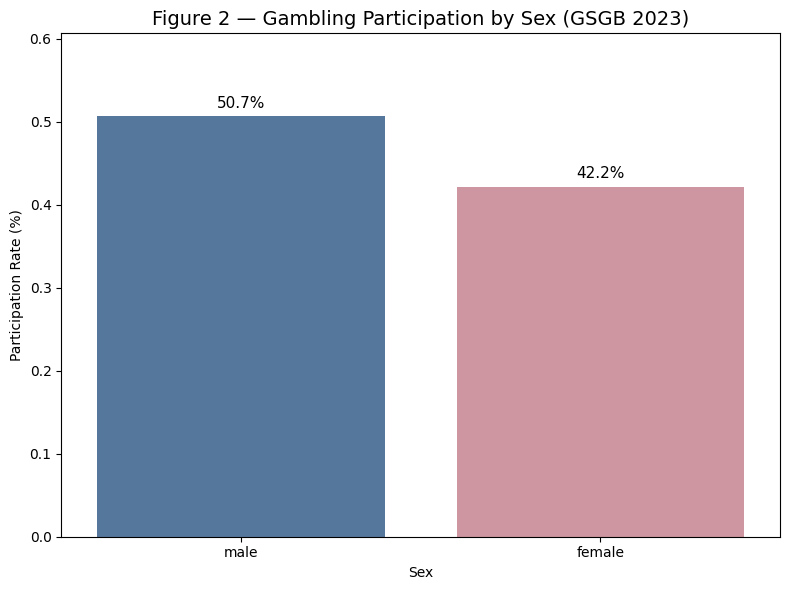

In [8]:
# ==========================================================
# GSGB Figure 2 — Participation by Sex (GSGB 2023)
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load model-ready A.8
df_a8 = pd.read_parquet("data/processed/model-ready/gsgb_a8_model_ready.parquet")

# Filter for sex rows
df_sex = df_a8[df_a8["group_type"] == "sex"].copy()
df_sex["sex"] = df_sex["sex"].str.lower().str.strip()

# Keep only male / female
df_sex = df_sex[df_sex["sex"].isin(["male", "female"])]

# Colour palette
palette = {"male": "#4a76a8", "female": "#d88c9a"}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_sex,
    x="sex",
    y="pct_all",
    hue="sex",
    palette=palette,
    legend=False
)

# Annotate % values
for i, v in enumerate(df_sex["pct_all"]):
    plt.text(i, v + 0.01, f"{v*100:.1f}%", ha="center", fontsize=11)

plt.title(
    "Figure 2 — Gambling Participation by Sex (GSGB 2023)",
    fontsize=14
)
plt.xlabel("Sex")
plt.ylabel("Participation Rate (%)")
plt.ylim(0, df_sex["pct_all"].max() + 0.10)
plt.tight_layout()
plt.show()


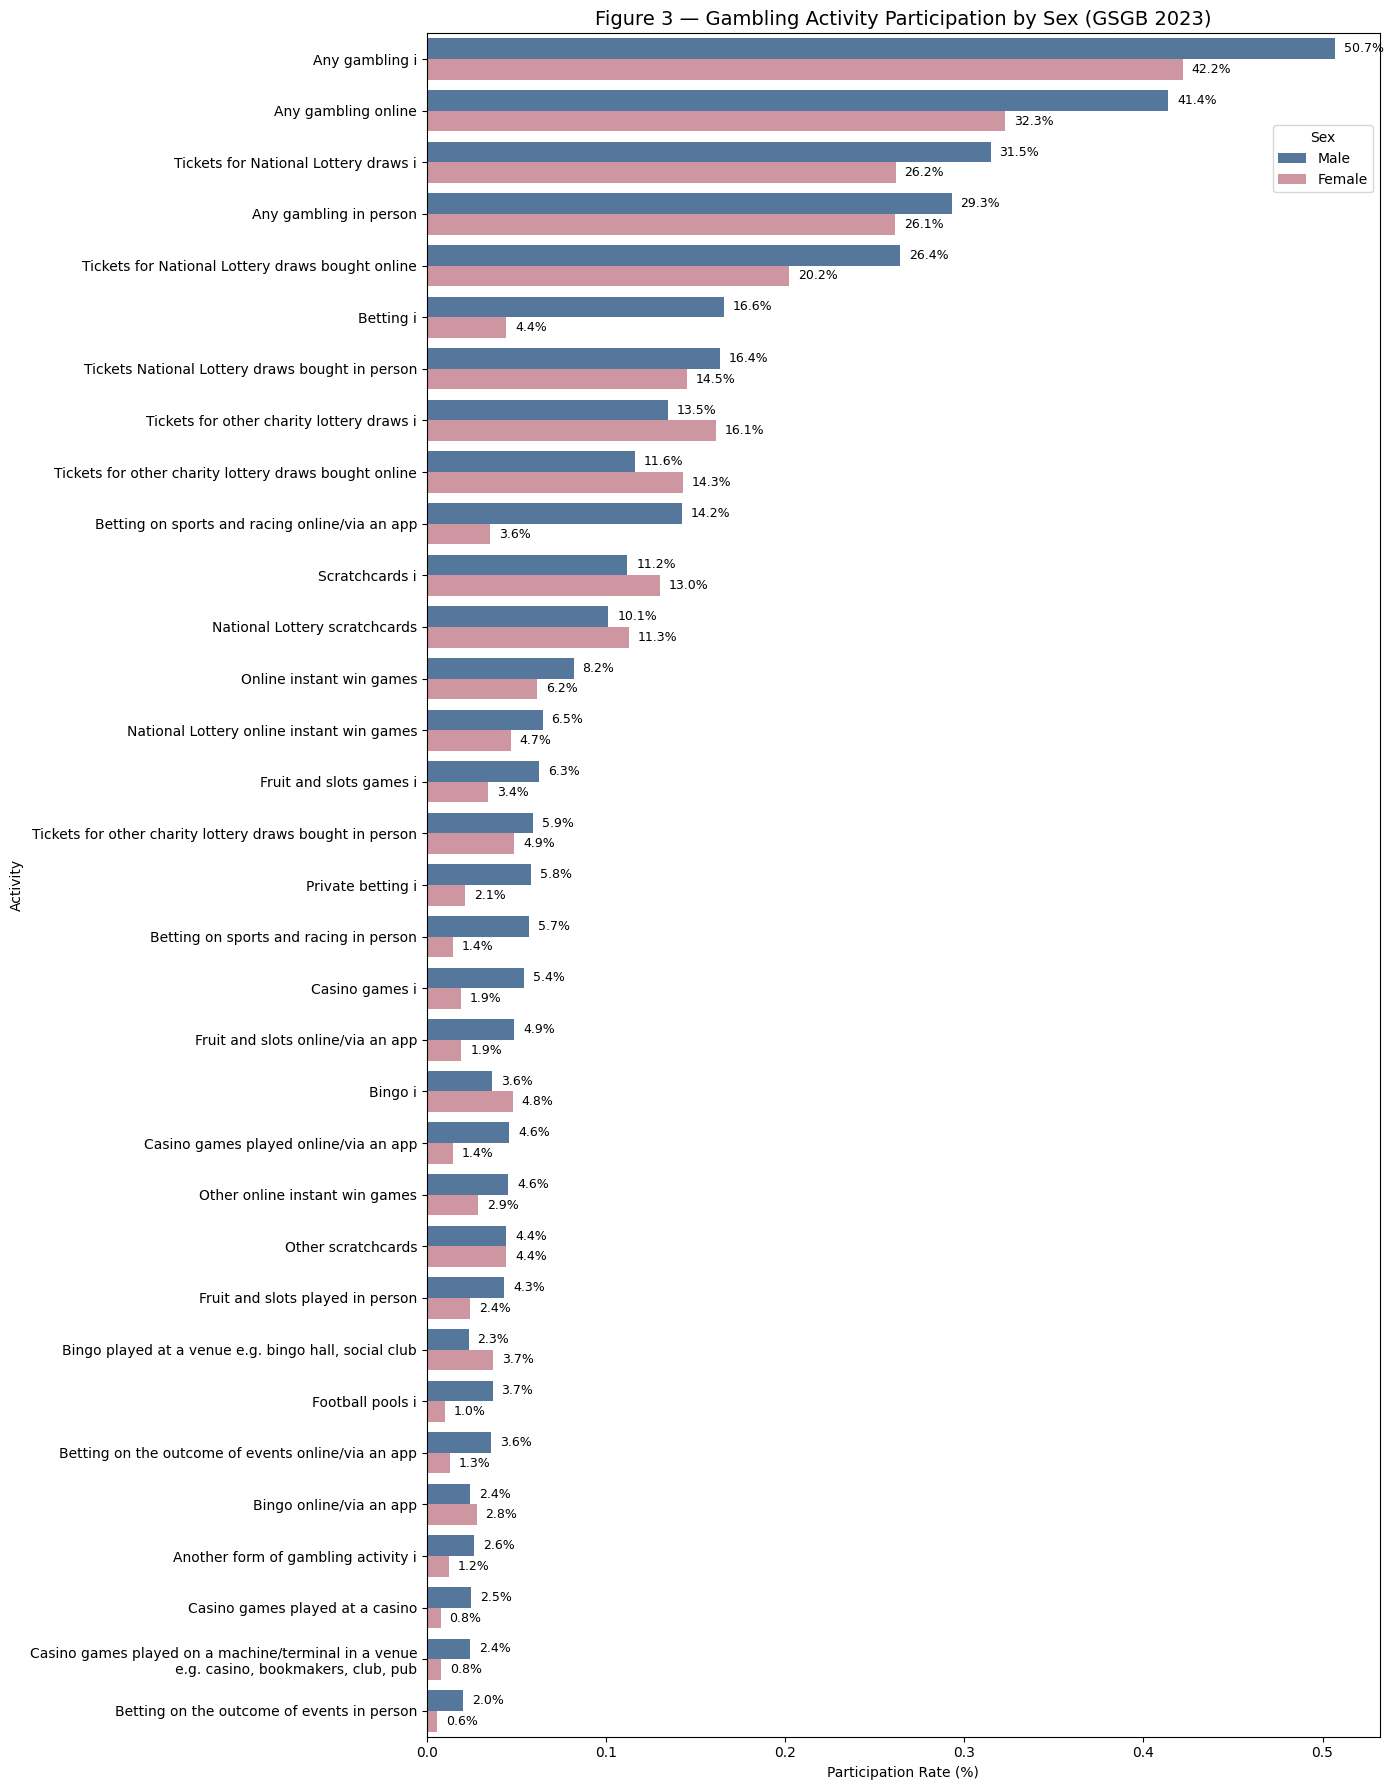

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load model-ready table A.11
df_a11 = pd.read_parquet("data/processed/model-ready/gsgb_a11_model_ready.parquet")

# Keep *only* real activities (remove bases, footnotes)
df_plot = df_a11[~df_a11["activity"].str.contains("base", case=False, na=False)].copy()
df_plot = df_plot.dropna(subset=["activity"])

# Rename columns to short names
df_plot = df_plot.rename(columns={
    "All males\n(percentage)": "male_pct",
    "All females\n(percentage)": "female_pct"
})

# Long → wide to tidy
df_long = df_plot.melt(
    id_vars=["activity"],
    value_vars=["male_pct", "female_pct"],
    var_name="sex",
    value_name="pct"
)

df_long["sex"] = df_long["sex"].map({"male_pct": "Male", "female_pct": "Female"})

# Sort so long labels stay readable
df_long = df_long.sort_values(by="pct", ascending=False)

plt.figure(figsize=(14, 18))

ax = sns.barplot(
    data=df_long,
    y="activity",
    x="pct",
    hue="sex",
    palette={"Male": "#4a76a8", "Female": "#d88c9a"}
)

# --------------------------------------- #
# FIXED LABEL ALIGNMENT + CLEAN PERCENT   #
# --------------------------------------- #

for container in ax.containers:
    for bar in container:
        value = bar.get_width()
        ax.text(
            value + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{value*100:.1f}%",
            va="center",
            ha="left",
            fontsize=9
        )
# ---------------------------- #
# MOVE LEGEND DOWN BY ~0.5 cm #
# ---------------------------- #
plt.legend(
    title="Sex",
    loc="upper right",
    bbox_to_anchor=(1, 0.95)  # shifted down slightly
)

# Formatting
plt.title("Figure 3 — Gambling Activity Participation by Sex (GSGB 2023)", fontsize=14)
plt.xlabel("Participation Rate (%)")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()


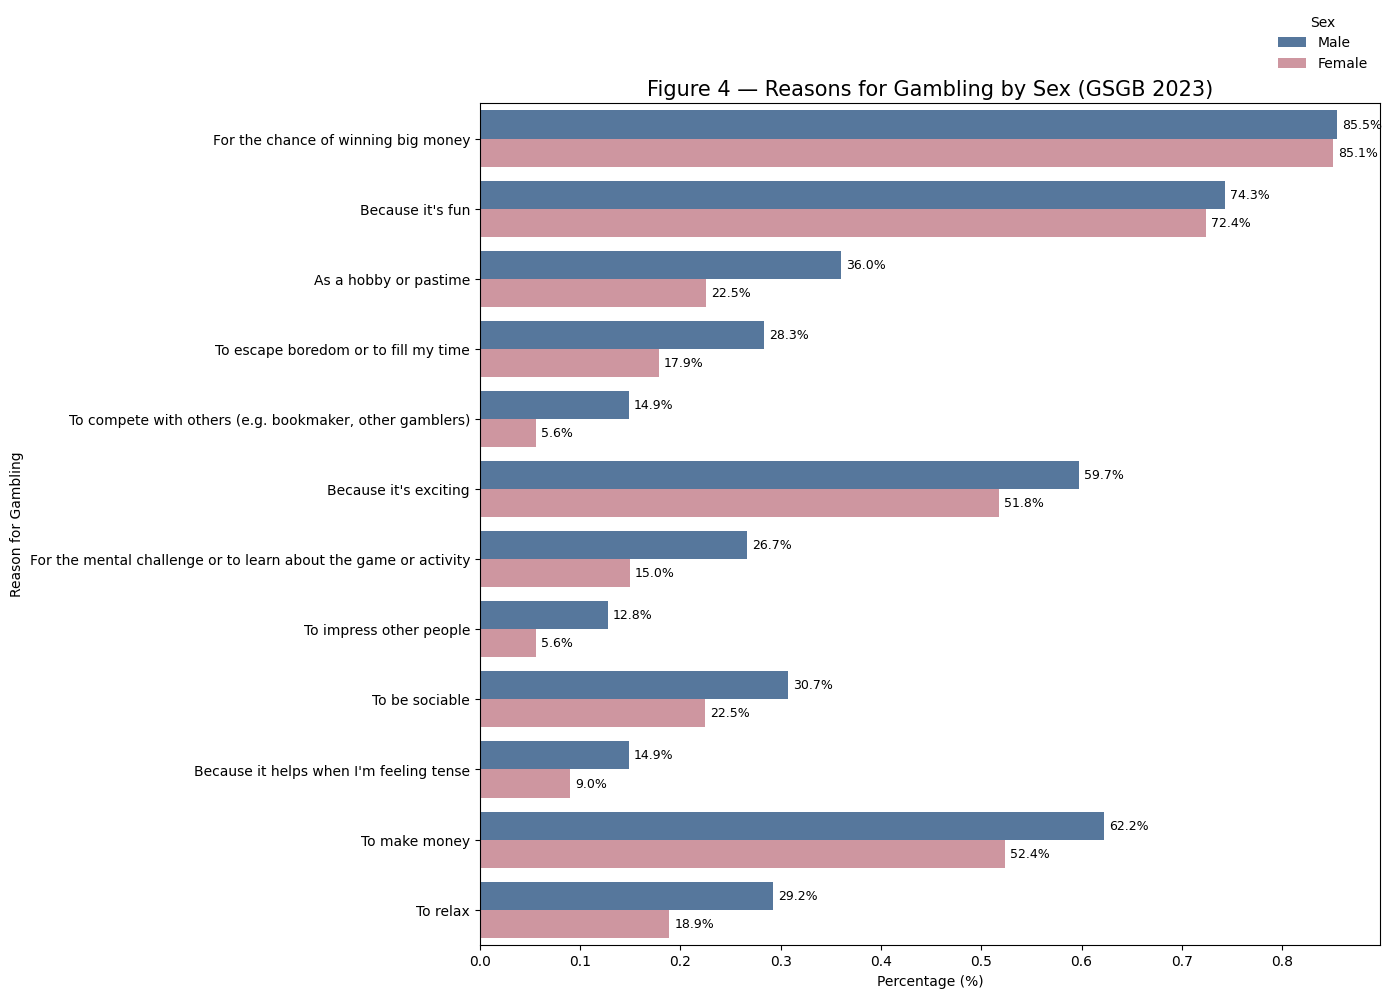

In [13]:
# Figure 4 — Legend Moved Below Title
plt.figure(figsize=(14, 10))

ax = sns.barplot(
    data=df_long,
    y="reason",
    x="pct",
    hue="sex",
    palette={"Male": "#4a76a8", "Female": "#d88c9a"}
)

# Label formatting
for container in ax.containers:
    for bar in container:
        value = bar.get_width()
        ax.text(
            value + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{value*100:.1f}%",
            va="center",
            ha="left",
            fontsize=9
        )

plt.title("Figure 4 — Reasons for Gambling by Sex (GSGB 2023)", fontsize=15)
plt.xlabel("Percentage (%)")
plt.ylabel("Reason for Gambling")

# ----------------------------------------------------
# ⭐ NEW: Move legend below the title (no overlap)
# ----------------------------------------------------
plt.legend(
    title="Sex",
    loc="upper right",
    bbox_to_anchor=(1.0, 1.12),   # ← pushes legend BELOW the title
    frameon=False
)

plt.tight_layout()
plt.show()


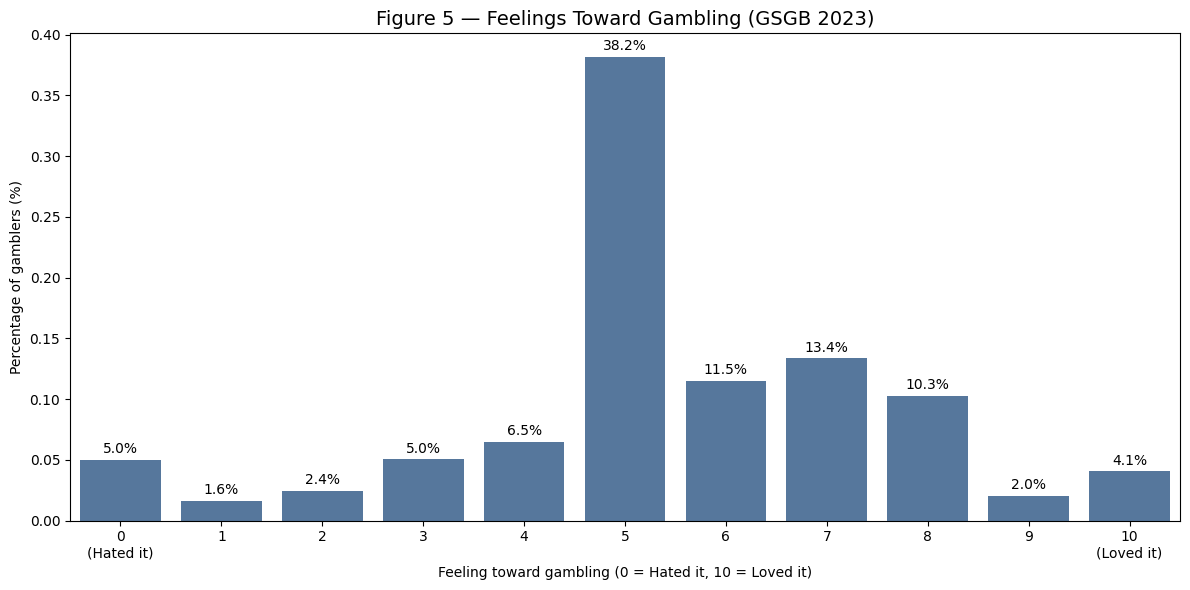

In [11]:
# =====================================================
# Figure 5 — Feelings Toward Gambling (GSGB 2023)
# =====================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_a15 = pd.read_parquet("data/processed/model-ready/gsgb_a15_model_ready.parquet")

# Sort by numeric score
df_plot = df_a15.sort_values("feeling_score")

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_plot,
    x="feeling_score",
    y="pct_all_gamblers",
    color="#4a76a8"
)

# Annotate
for i, v in enumerate(df_plot["pct_all_gamblers"]):
    plt.text(
        i,
        v + 0.003,
        f"{v*100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# X-axis labels: add label below score
xlabels = [
    f"{row.feeling_score}\n({row.feeling_label})" if row.feeling_label else f"{row.feeling_score}"
    for _, row in df_plot.iterrows()
]

plt.xticks(range(len(df_plot)), xlabels)

plt.title("Figure 5 — Feelings Toward Gambling (GSGB 2023)", fontsize=14)
plt.xlabel("Feeling toward gambling (0 = Hated it, 10 = Loved it)")
plt.ylabel("Percentage of gamblers (%)")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD MODEL-READY DATASETS
# ============================================================
a8  = pd.read_parquet("data/processed/model-ready/gsgb_a8_model_ready.parquet")
a11 = pd.read_parquet("data/processed/model-ready/gsgb_a11_model_ready.parquet")
a14 = pd.read_parquet("data/processed/model-ready/gsgb_a14_model_ready.parquet")
a15 = pd.read_parquet("data/processed/model-ready/gsgb_a15_model_ready.parquet")

# ============================================================
# PATCH A.8 — Remove footnotes / metadata rows fully
# ============================================================
# Remove all rows where pct fields are all missing → guaranteed metadata rows
num_cols = ["pct_all", "pct_no_lottery", "unweighted_n", "weighted_n"]
a8 = a8.dropna(subset=num_cols, how="all")

# Remove group_type 'other'
a8 = a8[a8["group_type"].isin(["all", "sex", "age", "sex_age"])]

# Remove known footnote texts if any survived
a8 = a8[~a8["group_clean"].str.contains("Base", na=False)]
a8 = a8[~a8["group_clean"].str.contains("Table", na=False)]
a8 = a8[~a8["group_clean"].str.contains("excluding", na=False)]
a8 = a8[~a8["group_clean"].str.contains("not be derived", na=False)]


# ============================================================
# PATCH A.11 — Remove footnote row
# ============================================================
pct_cols_11 = [
    "All participants\n(percentage)",
    "All males\n(percentage)",
    "All females\n(percentage)"
]

a11 = a11.dropna(subset=pct_cols_11, how="all")


# ============================================================
# PATCH A.14 — Remove Base/footer row
# ============================================================
pct_cols_14 = [c for c in a14.columns if "(percentage)" in c]

# Remove metadata where all percentage columns are missing
a14 = a14.dropna(subset=pct_cols_14, how="all")

# Also remove explicit “Base:” or footnote rows if present
a14 = a14[~a14["reason"].str.contains("Base", na=False)]
a14 = a14[a14["reason"].notna()]


# ============================================================
# Combine cleaned versions
# ============================================================
datasets = {
    "A.8 Participation": a8,
    "A.11 Activities": a11,
    "A.14 Reasons": a14,
    "A.15 Feelings": a15
}

print("=== GSGB QUALITY CHECK REPORT===\n")

# ============================================================
# RUN QA CHECKS
# ============================================================
for name, df in datasets.items():
    print(f"\n--- {name} ---")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    
    # Missing values
    missing = df.isna().sum()
    print("\nMissing values:")
    print(missing[missing > 0] if missing.sum() > 0 else "None")
    
    # Duplicates
    dups = df.duplicated().sum()
    print(f"\nDuplicate rows: {dups}")
    
    # Percentage range check
    pct_cols = [c for c in df.columns if "pct" in c.lower()]
    if pct_cols:
        print("\nPercentage column checks:") 
        for c in pct_cols:
            invalid = df[(df[c] < 0) | (df[c] > 1)]
            if invalid.shape[0] > 0:
                print(f"  ! Out-of-range values in {c}:")
                display(invalid)
            else:
                print(f"  {c}: OK")
    
    # Category checks for A.8 only
    if name == "A.8 Participation":
        print("\nGroup Type Categories:", df["group_type"].unique())
        print("Sex Categories:", df["sex"].unique())
        print("Age Group Categories:", df["age_group"].unique())


=== GSGB QUALITY CHECK REPORT===


--- A.8 Participation ---
Rows: 24, Columns: 10

Missing values:
sex          8
age_group    3
dtype: int64

Duplicate rows: 0

Percentage column checks:
  pct_all: OK
  pct_no_lottery: OK

Group Type Categories: ['all' 'sex' 'age' 'sex_age']
Sex Categories: [None 'male' 'female']
Age Group Categories: [None '18 to 24' '25 to 34' '35 to 44' '45 to 54' '55 to 64' '65 to 74'
 '75 plus']

--- A.11 Activities ---
Rows: 35, Columns: 5

Missing values:
None

Duplicate rows: 0

--- A.14 Reasons ---
Rows: 14, Columns: 12

Missing values:
None

Duplicate rows: 0

--- A.15 Feelings ---
Rows: 11, Columns: 5

Missing values:
None

Duplicate rows: 0

Percentage column checks:
  pct_all_gamblers: OK
  pct_excl_lottery_only: OK


=== A.2 — Lottery vs Non-Lottery Participation Differences (GSGB 2023) ===


,age_group,pct_all,pct_no_lottery,abs_diff,rel_diff
3,18 to 24,0.375285,0.348435,0.026850,0.071546
4,25 to 34,0.415999,0.342749,0.073250,0.176082
5,35 to 44,0.528024,0.360006,0.168018,0.318201
6,45 to 54,0.519635,0.273869,0.245766,0.472958
7,55 to 64,0.518984,0.245724,0.273260,0.526529
8,65 to 74,0.447515,0.174116,0.273399,0.610927
9,75 plus,0.375131,0.136214,0.238917,0.636889


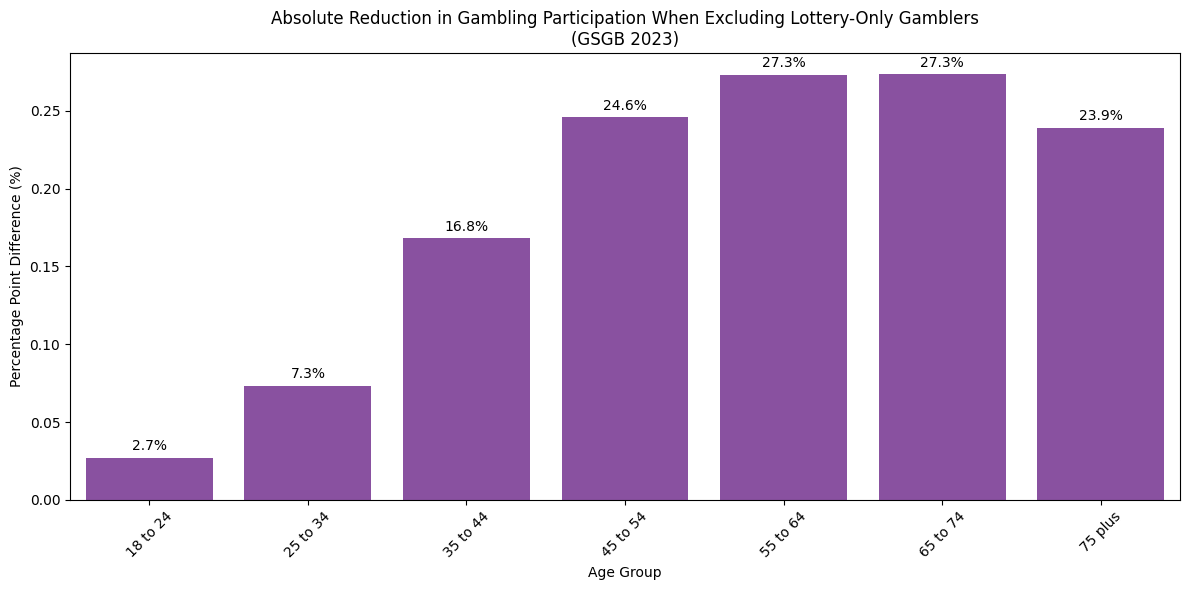

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_parquet("data/processed/model-ready/gsgb_a8_model_ready.parquet")

# Filter only age groups (clean comparative subset)
df_age = df[df["group_type"] == "age"].copy()

# Sort age groups
df_age["sort"] = df_age["age_group"].str.extract(r"^(\d+)").astype(int)
df_age = df_age.sort_values("sort")

# Calculate differences
df_age["abs_diff"] = df_age["pct_all"] - df_age["pct_no_lottery"]
df_age["rel_diff"] = df_age["abs_diff"] / df_age["pct_all"]

print("=== A.2 — Lottery vs Non-Lottery Participation Differences (GSGB 2023) ===")
display(df_age[["age_group", "pct_all", "pct_no_lottery", "abs_diff", "rel_diff"]])

# -----------------------------
# Visualisation: New Figure
# -----------------------------

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_age,
    x="age_group",
    y="abs_diff",
    color="#8e44ad"
)

# Annotate
for i, v in enumerate(df_age["abs_diff"]):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha="center")

plt.title("Absolute Reduction in Gambling Participation When Excluding Lottery-Only Gamblers\n(GSGB 2023)")
plt.ylabel("Percentage Point Difference (%)")
plt.xlabel("Age Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# harmonised GSGB participation (sex & age) with robust age parsing


GSGB age raw unique (head):
age_group_harmonised
18 to 24    3
25 to 34    3
35 to 44    3
45 to 54    3
55 to 64    3
65 to 74    3
75 plus     3
Name: count, dtype: int64

GSGB age7 counts (keep rows where age7 not null):
age7
NaN      9
18–24    3
35–44    3
25–34    3
45–54    3
55–64    3
65–74    3
75+      3
Name: count, dtype: int64

=== Table: sex_all ===


,sex_harmonised,n,mean_pct,min_pct,max_pct,mean_pct_%
0,female,8,0.410068,0.257164,0.514095,41.0
1,male,8,0.502265,0.421402,0.562947,50.2
2,missing,14,0.455539,0.375131,0.528024,45.6



=== Table: sex_nolot ===


,sex_harmonised,n,mean_pct,min_pct,max_pct,mean_pct_%
0,female,8,0.225176,0.136881,0.331913,22.5
1,male,8,0.314957,0.135520,0.470243,31.5
2,missing,14,0.269725,0.136214,0.360006,27.0



=== Table: age_all ===


,age7,n,mean_pct,min_pct,max_pct,mean_pct_%
0,18–24,3,0.375293,0.257164,0.493431,37.5
1,25–34,3,0.416365,0.379330,0.453767,41.6
2,35–44,3,0.527908,0.514095,0.541605,52.8
3,45–54,3,0.519750,0.502530,0.537086,52.0
4,55–64,3,0.518746,0.474307,0.562947,51.9
5,65–74,3,0.449767,0.400657,0.501128,45.0
6,75+,3,0.375655,0.330432,0.421402,37.6



=== Table: age_nolot ===


,age7,n,mean_pct,min_pct,max_pct,mean_pct_%
0,18–24,3,0.348431,0.226614,0.470243,34.8
1,25–34,3,0.343251,0.292504,0.394501,34.3
2,35–44,3,0.359991,0.331913,0.388052,36.0
3,45–54,3,0.275209,0.233967,0.317792,27.5
4,55–64,3,0.245457,0.195657,0.294992,24.5
5,65–74,3,0.173924,0.151375,0.196281,17.4
6,75+,3,0.136205,0.135520,0.136881,13.6


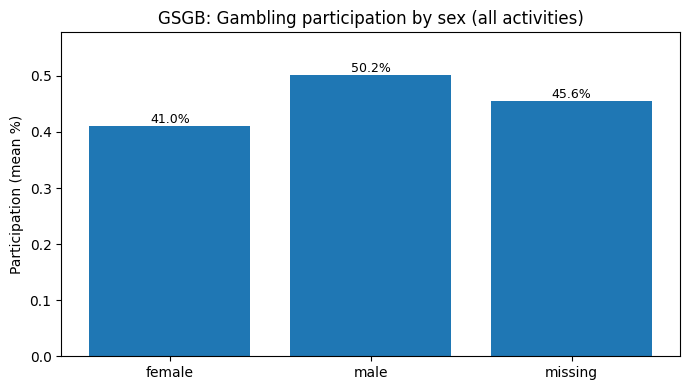

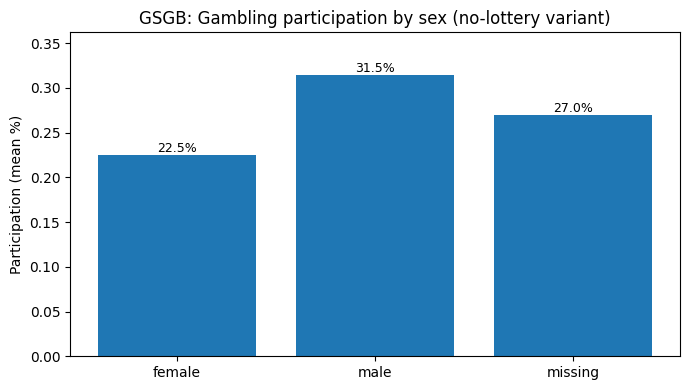

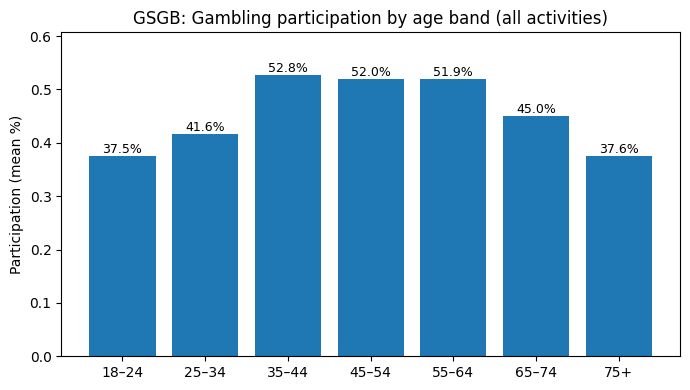

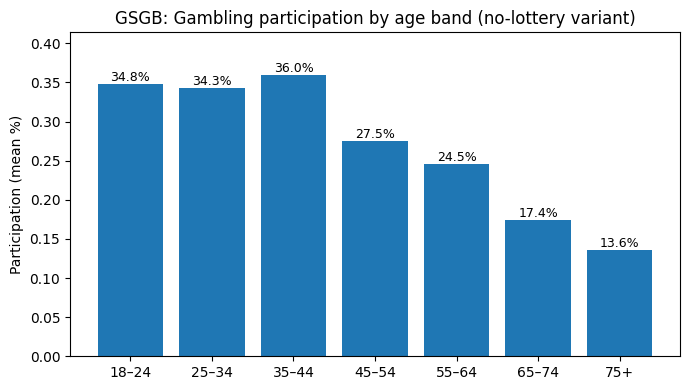

In [4]:
# === GSGB participation: sex & age summaries (robust to GSGB label formats) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gsgb = pd.read_parquet("data/processed/harmonised/gsgb_harmonised.parquet").copy()

# Keep only what we need (but be robust to what's there)
cols_wanted = ["survey_year_harmonised","sex_harmonised",
               "age_group_harmonised","age_group","group_type",
               "pct_all","pct_no_lottery","weighted_n","unweighted_n"]
present = [c for c in cols_wanted if c in gsgb.columns]
df = gsgb[present].copy()

# ---- Fix % scaling (handle 0–100 vs 0–1) ----
for c in ["pct_all","pct_no_lottery"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        if df[c].dropna().max() > 1.5:
            df[c] = df[c] / 100.0

# ---- SEX clean ----
if "sex_harmonised" in df.columns:
    df["sex_harmonised"] = (df["sex_harmonised"]
                            .replace({"None":"missing"})
                            .fillna("missing"))
    df["sex_harmonised"] = pd.Categorical(df["sex_harmonised"],
                                          categories=["female","male","missing"])

# ---- AGE: use harmonised if present, else fallback to GSGB's own 'age_group' when group_type=='age' ----
def to_age7_label(s: str):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return np.nan
    x = str(s).strip().lower()

    # Normalise common GSGB variants to numeric lower bounds
    # Examples seen: "16-24", "16 to 24", "25-34", "35–44", "75+", "75 plus"
    x = x.replace("to", "-").replace("plus", "+").replace(" ", "")
    x = x.replace("–", "-")  # en-dash to hyphen

    if x in {"75+", "75+years", "75", "80-84", "85+"}:
        return "75+"

    # Extract left bound if hyphenated
    lb = None
    if "-" in x:
        try:
            lb = int("".join([c for c in x.split("-")[0] if c.isdigit()]))
        except Exception:
            lb = None

    # If left bound still None, try any digits at beginning
    if lb is None:
        digs = "".join([c for c in x if c.isdigit()])
        lb = int(digs) if digs else None

    if lb is None:
        return np.nan

    # Map to 7 bands (note: GSGB often starts at 16; we place 16–24 into 18–24 bucket)
    if lb < 25:   return "18–24"
    if lb < 35:   return "25–34"
    if lb < 45:   return "35–44"
    if lb < 55:   return "45–54"
    if lb < 65:   return "55–64"
    if lb < 75:   return "65–74"
    return "75+"

# Build a single 'age7' column from best available source
if "age_group_harmonised" in df.columns and df["age_group_harmonised"].notna().any():
    age_source = df["age_group_harmonised"].fillna(np.nan)
else:
    # prefer rows that are actually age rows if present
    if "group_type" in df.columns and "age_group" in df.columns:
        age_source = np.where(df["group_type"].astype(str).str.lower().eq("age"),
                              df["age_group"], np.nan)
        age_source = pd.Series(age_source, index=df.index)
    elif "age_group" in df.columns:
        age_source = df["age_group"]
    else:
        age_source = pd.Series(np.nan, index=df.index)

df["age7"] = age_source.map(to_age7_label)
df["age7"] = pd.Categorical(df["age7"],
                            categories=["18–24","25–34","35–44","45–54","55–64","65–74","75+"],
                            ordered=True)

# ---- quick diagnostics (optional) ----
print("\nGSGB age raw unique (head):")
print(pd.Series(age_source).dropna().astype(str).value_counts().head(20))
print("\nGSGB age7 counts (keep rows where age7 not null):")
print(df["age7"].value_counts(dropna=False))

# =========================
# Tables (no FutureWarnings)
# =========================
tables = {}

def summarise_pct(df_grp, col):
    return df_grp.agg(n=("pct_all","size"),
                      mean_pct=(col,"mean"),
                      min_pct=(col,"min"),
                      max_pct=(col,"max"))

# By sex
if {"sex_harmonised","pct_all"} <= set(df.columns):
    tables["sex_all"] = summarise_pct(df.groupby("sex_harmonised", observed=True), "pct_all").reset_index()
if {"sex_harmonised","pct_no_lottery"} <= set(df.columns):
    tables["sex_nolot"] = summarise_pct(df.groupby("sex_harmonised", observed=True), "pct_no_lottery").reset_index()

# By age7  (drop NA age rows)
dfa = df.dropna(subset=["age7"])
if {"age7","pct_all"} <= set(dfa.columns):
    tables["age_all"] = summarise_pct(dfa.groupby("age7", observed=True), "pct_all").reset_index()
if {"age7","pct_no_lottery"} <= set(dfa.columns):
    tables["age_nolot"] = summarise_pct(dfa.groupby("age7", observed=True), "pct_no_lottery").reset_index()

# Show tables with % nicely
for name, t in tables.items():
    out = t.copy()
    if "mean_pct" in out:
        out["mean_pct_%"] = (out["mean_pct"]*100).round(1)
    print(f"\n=== Table: {name} ===")
    display(out)

# =========
# Bar plots
# =========
def bar_with_labels(x, y, title, ylabel="Participation (mean %)"):
    plt.figure(figsize=(7,4))
    plt.bar(x, y)
    ax = plt.gca()
    for i, v in enumerate(y):
        if not np.isnan(v):
            ax.text(i, v, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.title(title)
    plt.ylabel(ylabel)
    ymax = float(np.nanmax(y)) if len(y) else 0.01
    plt.ylim(0, max(0.01, ymax*1.15))
    plt.tight_layout()
    plt.show()

# Sex bars
if "sex_all" in tables:
    t = tables["sex_all"].copy()
    order = ["female","male","missing"]
    t["sex_harmonised"] = pd.Categorical(t["sex_harmonised"], categories=order)
    t = t.sort_values("sex_harmonised")
    bar_with_labels(t["sex_harmonised"].astype(str), t["mean_pct"].astype(float),
                    "GSGB: Gambling participation by sex (all activities)")
if "sex_nolot" in tables:
    t = tables["sex_nolot"].copy()
    order = ["female","male","missing"]
    t["sex_harmonised"] = pd.Categorical(t["sex_harmonised"], categories=order)
    t = t.sort_values("sex_harmonised")
    bar_with_labels(t["sex_harmonised"].astype(str), t["mean_pct"].astype(float),
                    "GSGB: Gambling participation by sex (no-lottery variant)")

# Age bars
if "age_all" in tables and len(tables["age_all"]) > 0:
    t = tables["age_all"].sort_values("age7")
    bar_with_labels(t["age7"].astype(str), t["mean_pct"].astype(float),
                    "GSGB: Gambling participation by age band (all activities)")
if "age_nolot" in tables and len(tables["age_nolot"]) > 0:
    t = tables["age_nolot"].sort_values("age7")
    bar_with_labels(t["age7"].astype(str), t["mean_pct"].astype(float),
                    "GSGB: Gambling participation by age band (no-lottery variant)")


In [11]:
# --- GSGB Narrative (text-only helper output) ---
print("GSGB participation — interpretation notes")
print("• Participation ‘all’ includes lottery products; ‘no-lottery’ isolates non-lottery gambling.")
print("• Typical pattern: male > female in overall participation; non-lottery rates are lower across all groups.")
print("• By age, participation often rises from 25–34 into midlife, then tapers after 65–74; check your table values.")
print("• Use the ‘no-lottery’ series to discuss policy-relevant forms (e.g., online betting) separately from lottery play.")


GSGB participation — interpretation notes
• Participation ‘all’ includes lottery products; ‘no-lottery’ isolates non-lottery gambling.
• Typical pattern: male > female in overall participation; non-lottery rates are lower across all groups.
• By age, participation often rises from 25–34 into midlife, then tapers after 65–74; check your table values.
• Use the ‘no-lottery’ series to discuss policy-relevant forms (e.g., online betting) separately from lottery play.
